In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score
import os

In [2]:
tf.random.set_seed(42)
np.random.seed(42)


In [3]:
# Load CIFAR-10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


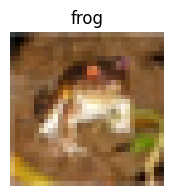

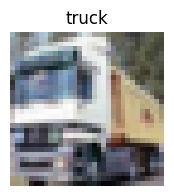

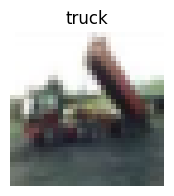

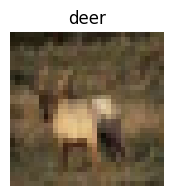

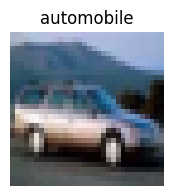

In [4]:
import matplotlib.pyplot as plt

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

def show_image(index):
  if index<0 or index>=len(x_train):
    return

  plt.figure(figsize=(2,2))
  plt.imshow(x_train[i])
  plt.title(class_names[y_train[i][0]])
  plt.axis('off')
  plt.show()

for i in range(5):
  show_image(i)



In [5]:

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

num_classes = 10
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("y_train_cat shape:", y_train_cat.shape)
print("y_test_cat shape:", y_test_cat.shape)

x_train shape: (50000, 32, 32, 3)
x_test shape: (10000, 32, 32, 3)
y_train_cat shape: (50000, 10)
y_test_cat shape: (10000, 10)


In [6]:
def build_cnn():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (5, 5), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (7, 7), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_cnn()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 980,810 (3.74 MB)

 Trainable params: 980,810 (3.74 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
checkpoint_path = "cnn_cifar10_best_model.keras"

callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
    ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True)
]

start_time = time.time()

history = model.fit(
    x_train, y_train_cat,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

training_time = time.time() - start_time
print(f"Training Time: {training_time:.2f} seconds")

model.save("cnn_cifar10_final.keras")
print("Model saved successfully.")

Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.4165 - loss: 1.5949 - val_accuracy: 0.5700 - val_loss: 1.2013
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5961 - loss: 1.1434 - val_accuracy: 0.6490 - val_loss: 1.0071
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6692 - loss: 0.9445 - val_accuracy: 0.6920 - val_loss: 0.8916
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7209 - loss: 0.8016 - val_accuracy: 0.7134 - val_loss: 0.8482
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7599 - loss: 0.6923 - val_accuracy: 0.7085 - val_loss: 0.8937
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7944 - loss: 0.5893 - val_accuracy: 0.7163 - val_loss: 0.9249
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8208 - loss: 0.5133 - val_accuracy: 0.7207 - val_loss: 0.8925
Epoch 8/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8423 - loss: 0.4432 - val_accuracy: 0

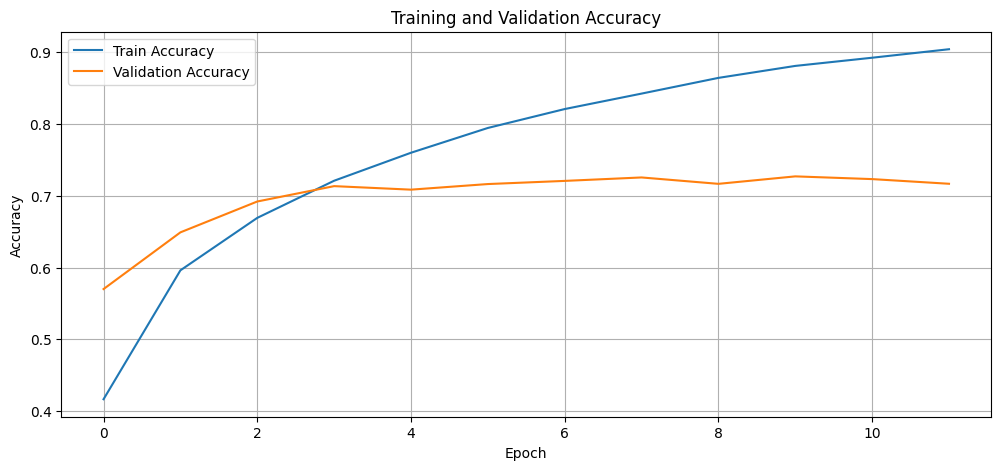

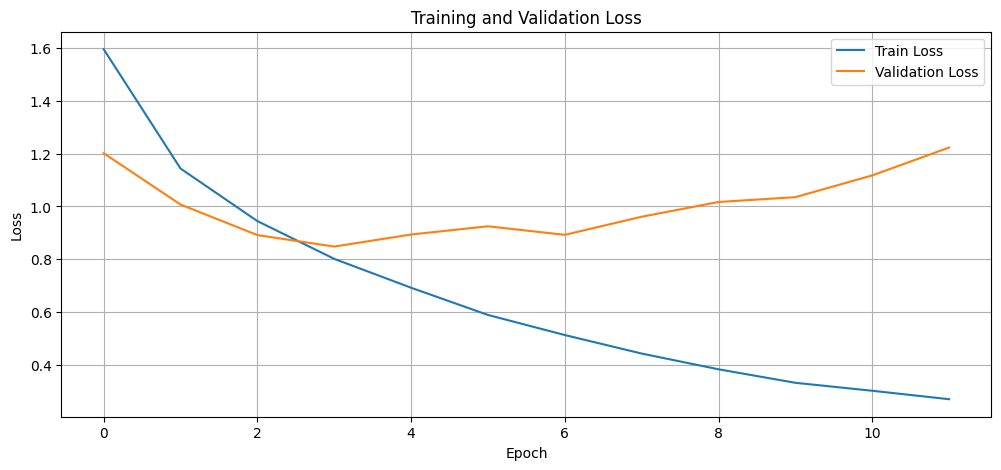

In [8]:
plt.figure(figsize=(12, 5))
plt.plot(history.history['accuracy'],label='Train Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(history.history['loss'],label='Train Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

In [9]:
model=tf.keras.models.load_model('cnn_cifar10_best_model.keras')
print("Best model Loaded.")


Best model Loaded.


In [10]:
def evaluate_model(model, x_data, y_true_cat, y_true_labels, attack_name="Clean Data"):
    loss, acc = model.evaluate(x_data, y_true_cat, verbose=0)

    y_pred_probs = model.predict(x_data, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    precision = precision_score(y_true_labels, y_pred, average='weighted')
    recall = recall_score(y_true_labels, y_pred, average='weighted')
    f1 = f1_score(y_true_labels, y_pred, average='weighted')

    cm = confusion_matrix(y_true_labels, y_pred)

    print(f"\n--- {attack_name} Evaluation ---")
    print(f"Loss: {loss:.4f}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_true_labels, y_pred, target_names=class_names))

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - {attack_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    return {
        "loss": loss,
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "confusion_matrix": cm
    }


--- Clean Data Evaluation ---
Loss: 1.0831
Accuracy: 0.7205
Precision: 0.7196
Recall: 0.7205
F1-score: 0.7175

Classification Report:
              precision    recall  f1-score   support

    airplane       0.72      0.78      0.75      1000
  automobile       0.82      0.85      0.83      1000
        bird       0.58      0.66      0.61      1000
         cat       0.62      0.42      0.50      1000
        deer       0.66      0.67      0.66      1000
         dog       0.64      0.63      0.63      1000
        frog       0.73      0.81      0.77      1000
       horse       0.77      0.80      0.78      1000
        ship       0.84      0.80      0.82      1000
       truck       0.81      0.78      0.80      1000

    accuracy                           0.72     10000
   macro avg       0.72      0.72      0.72     10000
weighted avg       0.72      0.72      0.72     10000



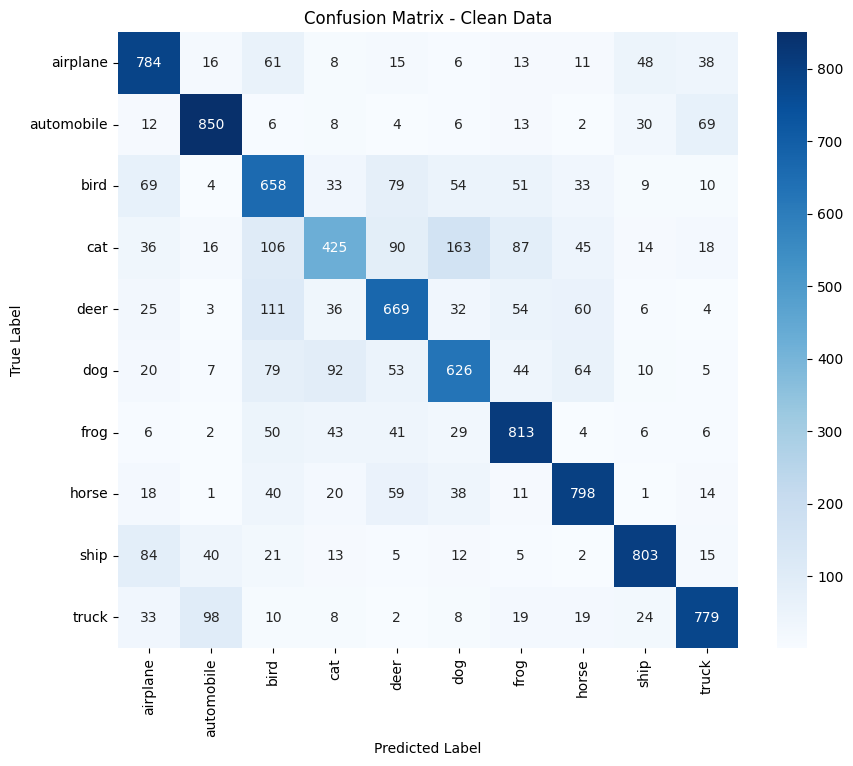

In [11]:
y_test_labels = y_test.flatten()

clean_results = evaluate_model(
    model,
    x_test,
    y_test_cat,
    y_test_labels,
    attack_name="Clean Data"
)

In [12]:
loss_object=tf.keras.losses.CategoricalCrossentropy()


In [13]:
def fgsm_attack(model, images, labels, epsilon=0.03):
    images=tf.convert_to_tensor(images)
    labels=tf.convert_to_tensor(labels)

    with tf.GradientTape() as tape:
        tape.watch(images)
        predictions=model(images)
        loss=loss_object(labels,predictions)

    gradient=tape.gradient(loss,images)
    signed_grad=tf.sign(gradient)
    adv_images=images+epsilon*signed_grad
    adv_images=tf.clip_by_value(adv_images,0.0,1.0)

    return adv_images.numpy()

In [14]:
def bim_attack(model, images, labels, epsilon=0.03, alpha=0.005, iterations=10):
    images=tf.convert_to_tensor(images)
    labels=tf.convert_to_tensor(labels)

    original_images=images
    adv_images=tf.identity(images)

    for i in range(iterations):
        with tf.GradientTape() as tape:
            tape.watch(adv_images)
            predictions=model(adv_images)
            loss=loss_object(labels,predictions)

        gradient=tape.gradient(loss,adv_images)
        signed_grad=tf.sign(gradient)

        adv_images=adv_images+alpha*signed_grad

        adv_images=tf.clip_by_value(adv_images,original_images-epsilon,original_images+epsilon)
        adv_images=tf.clip_by_value(adv_images,0.0,1.0)

    return adv_images.numpy()

In [23]:
def pgd_attack(model,images,labels,epsilon=0.03,alpha=0.005,iterations=20):
  images=tf.convert_to_tensor(images)
  labels=tf.convert_to_tensor(labels)

  adv_images=images+tf.random.uniform(tf.shape(images),-epsilon,epsilon)
  adv_images=tf.clip_by_value(adv_images,0,1)

  for i in range(iterations):
    with tf.GradientTape() as tape:
      tape.watch(adv_images)
      prediction=model(adv_images)
      loss=loss_object(labels,prediction)
    gradient=tape.gradient(loss,adv_images)
    singed_grad=tf.sign(gradient)

    adv_images=adv_images+alpha*singed_grad

    adv_images=tf.clip_by_value(adv_images,images-epsilon,images+epsilon)
    adv_images=tf.clip_by_value(adv_images,0,1)

  return adv_images.numpy()

In [18]:
def generate_adversarial_dataset(attack_fn,model,x_data,y_data,batch_size=256,**attack_params):
  adv_examples=[]
  n=len(x_data)

  for i in range(0,n,batch_size):
    x_batch=x_data[i:i+batch_size]
    y_batch=y_data[i:i+batch_size]

    adv_batch=attack_fn(model,x_batch,y_batch,**attack_params)
    adv_examples.append(adv_batch)

  return np.concatenate(adv_examples,axis=0)


Generating FGSM adversarial examples for epsilon = 0.01

--- FGSM (epsilon=0.01) Evaluation ---
Loss: 4.6094
Accuracy: 0.2949
Precision: 0.2999
Recall: 0.2949
F1-score: 0.2959

Classification Report:
              precision    recall  f1-score   support

    airplane       0.36      0.41      0.39      1000
  automobile       0.48      0.49      0.48      1000
        bird       0.14      0.20      0.16      1000
         cat       0.06      0.04      0.05      1000
        deer       0.11      0.11      0.11      1000
         dog       0.18      0.16      0.17      1000
        frog       0.35      0.35      0.35      1000
       horse       0.40      0.39      0.39      1000
        ship       0.53      0.43      0.47      1000
       truck       0.40      0.37      0.38      1000

    accuracy                           0.29     10000
   macro avg       0.30      0.29      0.30     10000
weighted avg       0.30      0.29      0.30     10000



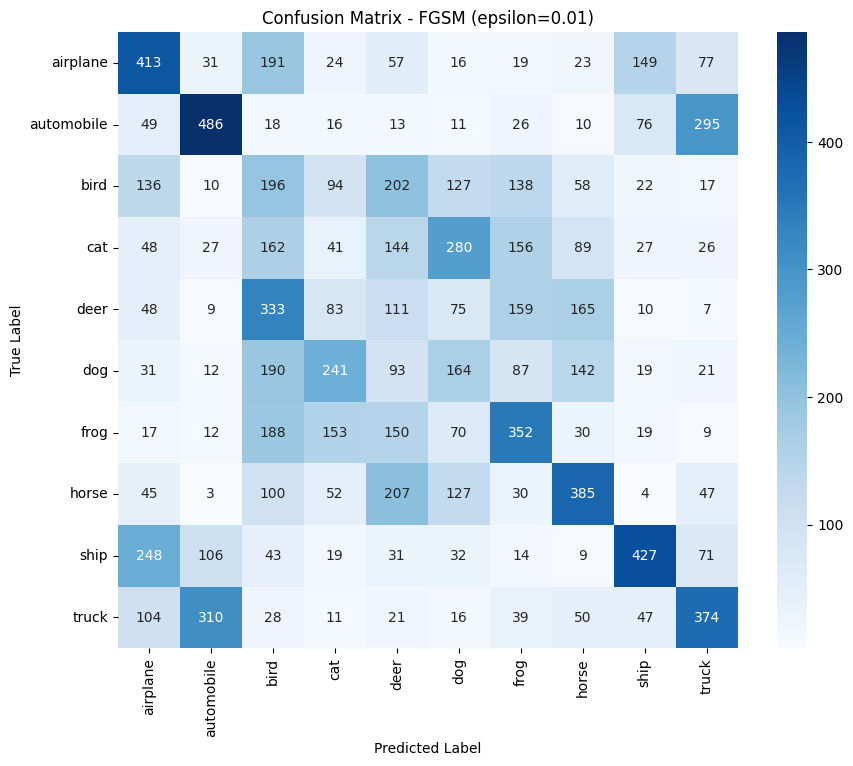


Generating FGSM adversarial examples for epsilon = 0.03

--- FGSM (epsilon=0.03) Evaluation ---
Loss: 10.6259
Accuracy: 0.0696
Precision: 0.0770
Recall: 0.0696
F1-score: 0.0723

Classification Report:
              precision    recall  f1-score   support

    airplane       0.11      0.12      0.11      1000
  automobile       0.16      0.15      0.15      1000
        bird       0.02      0.03      0.02      1000
         cat       0.00      0.00      0.00      1000
        deer       0.01      0.01      0.01      1000
         dog       0.02      0.02      0.02      1000
        frog       0.09      0.09      0.09      1000
       horse       0.16      0.13      0.14      1000
        ship       0.13      0.08      0.10      1000
       truck       0.08      0.08      0.08      1000

    accuracy                           0.07     10000
   macro avg       0.08      0.07      0.07     10000
weighted avg       0.08      0.07      0.07     10000



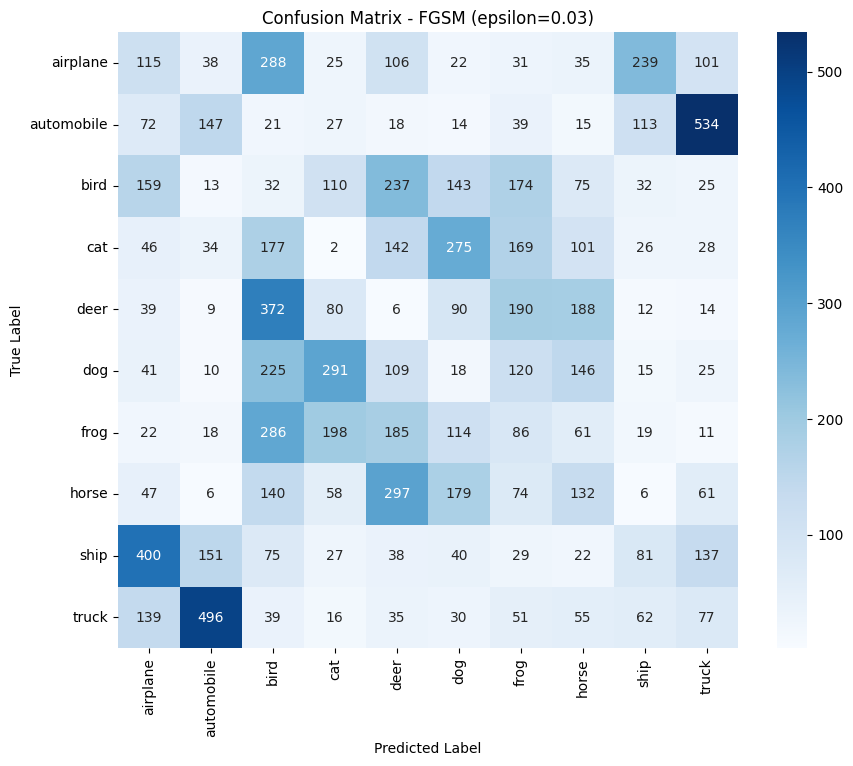


Generating FGSM adversarial examples for epsilon = 0.05

--- FGSM (epsilon=0.05) Evaluation ---
Loss: 13.8544
Accuracy: 0.0386
Precision: 0.0422
Recall: 0.0386
F1-score: 0.0399

Classification Report:
              precision    recall  f1-score   support

    airplane       0.04      0.04      0.04      1000
  automobile       0.08      0.07      0.08      1000
        bird       0.01      0.02      0.01      1000
         cat       0.00      0.00      0.00      1000
        deer       0.00      0.01      0.00      1000
         dog       0.01      0.01      0.01      1000
        frog       0.05      0.06      0.06      1000
       horse       0.14      0.12      0.13      1000
        ship       0.04      0.02      0.03      1000
       truck       0.04      0.04      0.04      1000

    accuracy                           0.04     10000
   macro avg       0.04      0.04      0.04     10000
weighted avg       0.04      0.04      0.04     10000



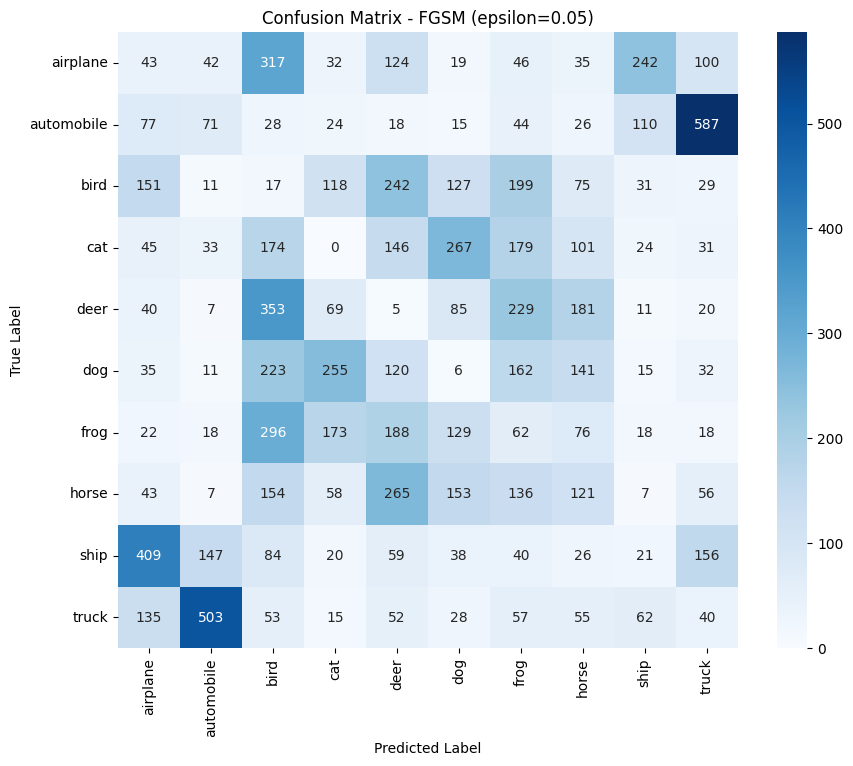


Generating FGSM adversarial examples for epsilon = 0.1

--- FGSM (epsilon=0.1) Evaluation ---
Loss: 16.8779
Accuracy: 0.0225
Precision: 0.0218
Recall: 0.0225
F1-score: 0.0209

Classification Report:
              precision    recall  f1-score   support

    airplane       0.01      0.01      0.01      1000
  automobile       0.02      0.01      0.01      1000
        bird       0.01      0.01      0.01      1000
         cat       0.00      0.00      0.00      1000
        deer       0.00      0.00      0.00      1000
         dog       0.00      0.00      0.00      1000
        frog       0.04      0.08      0.05      1000
       horse       0.12      0.09      0.10      1000
        ship       0.01      0.00      0.00      1000
       truck       0.02      0.02      0.02      1000

    accuracy                           0.02     10000
   macro avg       0.02      0.02      0.02     10000
weighted avg       0.02      0.02      0.02     10000



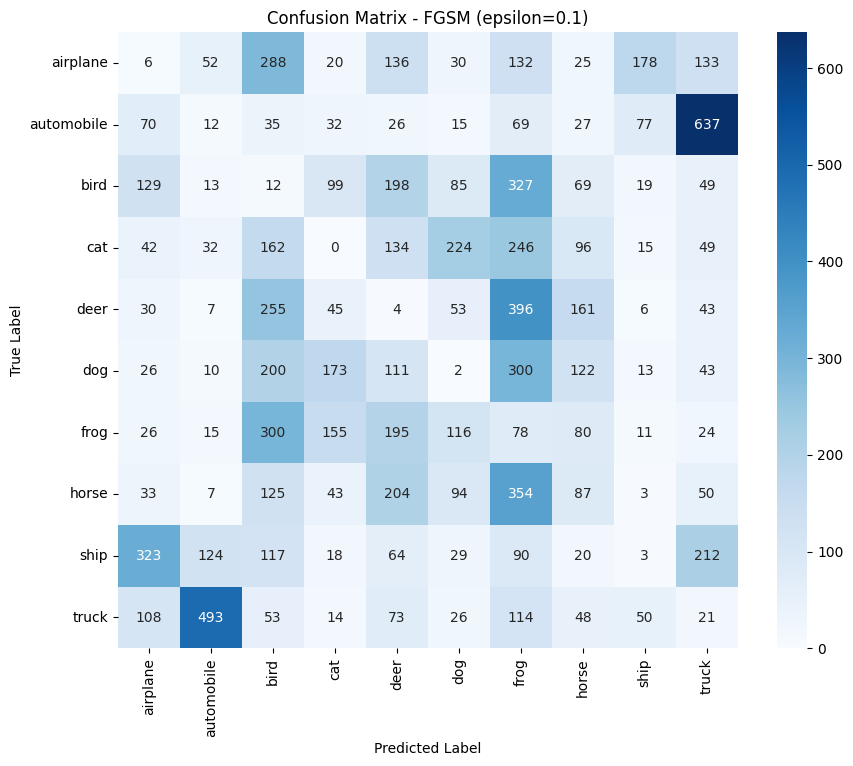

In [19]:
fgsm_epsilons = [0.01, 0.03, 0.05, 0.1]
fgsm_results = {}

for eps in fgsm_epsilons:
    print(f"\nGenerating FGSM adversarial examples for epsilon = {eps}")
    x_test_fgsm = generate_adversarial_dataset(
        fgsm_attack, model, x_test, y_test_cat, epsilon=eps
    )

    results = evaluate_model(
        model,
        x_test_fgsm,
        y_test_cat,
        y_test_labels,
        attack_name=f"FGSM (epsilon={eps})"
    )
    fgsm_results[eps] = results


Generating BIM adversarial examples...

--- BIM (epsilon=0.03, alpha=0.005, iter=10) Evaluation ---
Loss: 21.5813
Accuracy: 0.0113
Precision: 0.0126
Recall: 0.0113
F1-score: 0.0118

Classification Report:
              precision    recall  f1-score   support

    airplane       0.01      0.01      0.01      1000
  automobile       0.02      0.02      0.02      1000
        bird       0.00      0.00      0.00      1000
         cat       0.00      0.00      0.00      1000
        deer       0.00      0.00      0.00      1000
         dog       0.00      0.00      0.00      1000
        frog       0.00      0.00      0.00      1000
       horse       0.07      0.06      0.06      1000
        ship       0.01      0.01      0.01      1000
       truck       0.01      0.01      0.01      1000

    accuracy                           0.01     10000
   macro avg       0.01      0.01      0.01     10000
weighted avg       0.01      0.01      0.01     10000



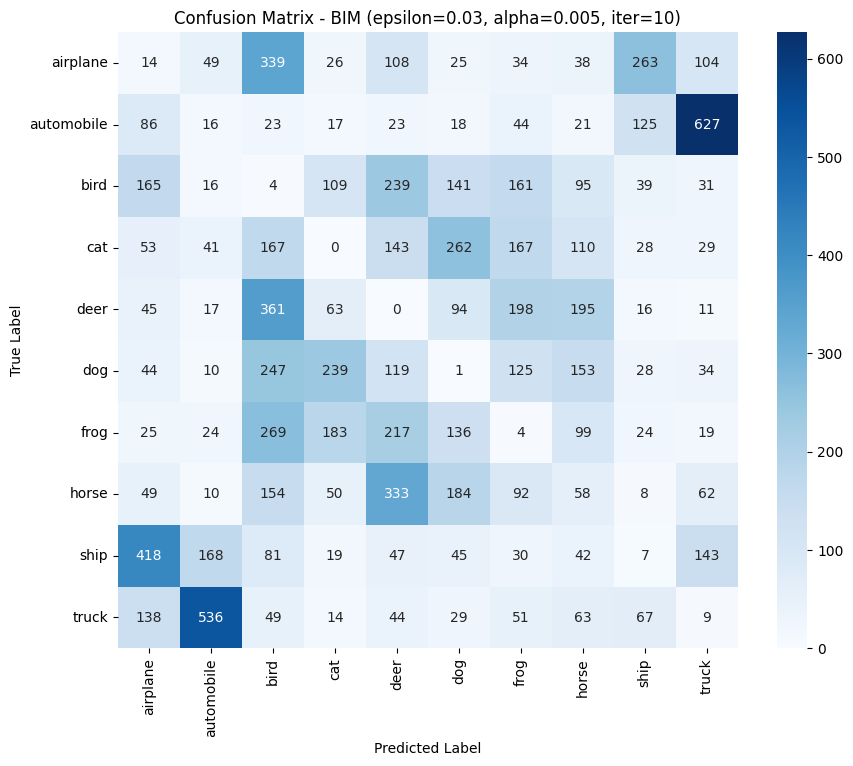

In [20]:
print("\nGenerating BIM adversarial examples...")
x_test_bim = generate_adversarial_dataset(
    bim_attack,
    model,
    x_test,
    y_test_cat,
    epsilon=0.03,
    alpha=0.005,
    iterations=10
)

bim_results = evaluate_model(
    model,
    x_test_bim,
    y_test_cat,
    y_test_labels,
    attack_name="BIM (epsilon=0.03, alpha=0.005, iter=10)"
)


Generating PGD adversarial examples...

--- PGD (epsilon=0.03, alpha=0.005, iter=20) Evaluation ---
Loss: 23.7080
Accuracy: 0.0069
Precision: 0.0078
Recall: 0.0069
F1-score: 0.0073

Classification Report:
              precision    recall  f1-score   support

    airplane       0.01      0.01      0.01      1000
  automobile       0.01      0.01      0.01      1000
        bird       0.00      0.00      0.00      1000
         cat       0.00      0.00      0.00      1000
        deer       0.00      0.00      0.00      1000
         dog       0.00      0.00      0.00      1000
        frog       0.00      0.00      0.00      1000
       horse       0.04      0.04      0.04      1000
        ship       0.01      0.01      0.01      1000
       truck       0.00      0.01      0.00      1000

    accuracy                           0.01     10000
   macro avg       0.01      0.01      0.01     10000
weighted avg       0.01      0.01      0.01     10000



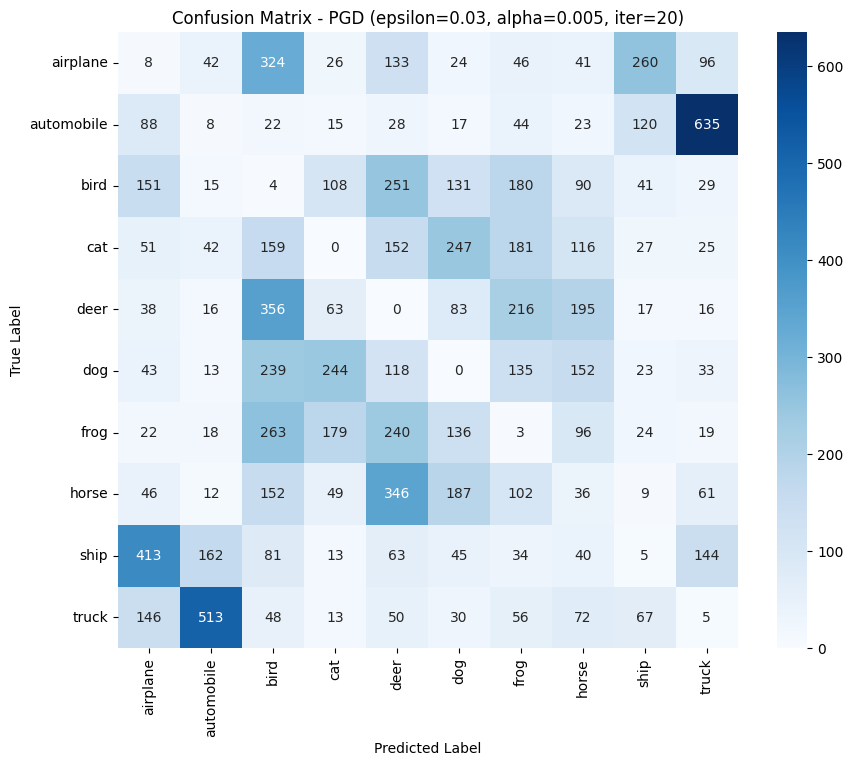

In [24]:
print("\nGenerating PGD adversarial examples...")
x_test_pgd = generate_adversarial_dataset(
    pgd_attack,
    model,
    x_test,
    y_test_cat,
    epsilon=0.03,
    alpha=0.005,
    iterations=20
)

pgd_results = evaluate_model(
    model,
    x_test_pgd,
    y_test_cat,
    y_test_labels,
    attack_name="PGD (epsilon=0.03, alpha=0.005, iter=20)"
)

In [25]:
results_summary = []

results_summary.append([
    "Clean",
    clean_results["loss"],
    clean_results["accuracy"],
    clean_results["precision"],
    clean_results["recall"],
    clean_results["f1_score"]
])

for eps, res in fgsm_results.items():
    results_summary.append([
        f"FGSM eps={eps}",
        res["loss"],
        res["accuracy"],
        res["precision"],
        res["recall"],
        res["f1_score"]
    ])

results_summary.append([
    "BIM",
    bim_results["loss"],
    bim_results["accuracy"],
    bim_results["precision"],
    bim_results["recall"],
    bim_results["f1_score"]
])

results_summary.append([
    "PGD",
    pgd_results["loss"],
    pgd_results["accuracy"],
    pgd_results["precision"],
    pgd_results["recall"],
    pgd_results["f1_score"]
])

print("\nFinal Comparison:")
print(f"{'Attack':<20} {'Loss':<10} {'Accuracy':<10} {'Precision':<10} {'Recall':<10} {'F1-score':<10}")
for row in results_summary:
    print(f"{row[0]:<20} {row[1]:<10.4f} {row[2]:<10.4f} {row[3]:<10.4f} {row[4]:<10.4f} {row[5]:<10.4f}")


Final Comparison:
Attack               Loss       Accuracy   Precision  Recall     F1-score  
Clean                1.0831     0.7205     0.7196     0.7205     0.7175    
FGSM eps=0.01        4.6094     0.2949     0.2999     0.2949     0.2959    
FGSM eps=0.03        10.6259    0.0696     0.0770     0.0696     0.0723    
FGSM eps=0.05        13.8544    0.0386     0.0422     0.0386     0.0399    
FGSM eps=0.1         16.8779    0.0225     0.0218     0.0225     0.0209    
BIM                  21.5813    0.0113     0.0126     0.0113     0.0118    
PGD                  23.7080    0.0069     0.0078     0.0069     0.0073    


In [26]:
def visualize_adversarial_examples(model, x_original, y_true, x_adversarial, class_names, num_examples=10):
    y_true = y_true.flatten()

    pred_original = np.argmax(model.predict(x_original[:num_examples], verbose=0), axis=1)
    pred_adv = np.argmax(model.predict(x_adversarial[:num_examples], verbose=0), axis=1)

    plt.figure(figsize=(15, num_examples * 3))

    for i in range(num_examples):
        # Original
        plt.subplot(num_examples, 3, i*3 + 1)
        plt.imshow(x_original[i])
        plt.title(f"Original\nTrue: {class_names[y_true[i]]}\nPred: {class_names[pred_original[i]]}")
        plt.axis('off')

        # Adversarial
        plt.subplot(num_examples, 3, i*3 + 2)
        plt.imshow(x_adversarial[i])
        plt.title(f"Adversarial\nPred: {class_names[pred_adv[i]]}")
        plt.axis('off')

        # Perturbation
        perturbation = x_adversarial[i] - x_original[i]
        perturbation_display = (perturbation - perturbation.min()) / (perturbation.max() - perturbation.min() + 1e-8)

        plt.subplot(num_examples, 3, i*3 + 3)
        plt.imshow(perturbation_display)
        plt.title("Perturbation")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

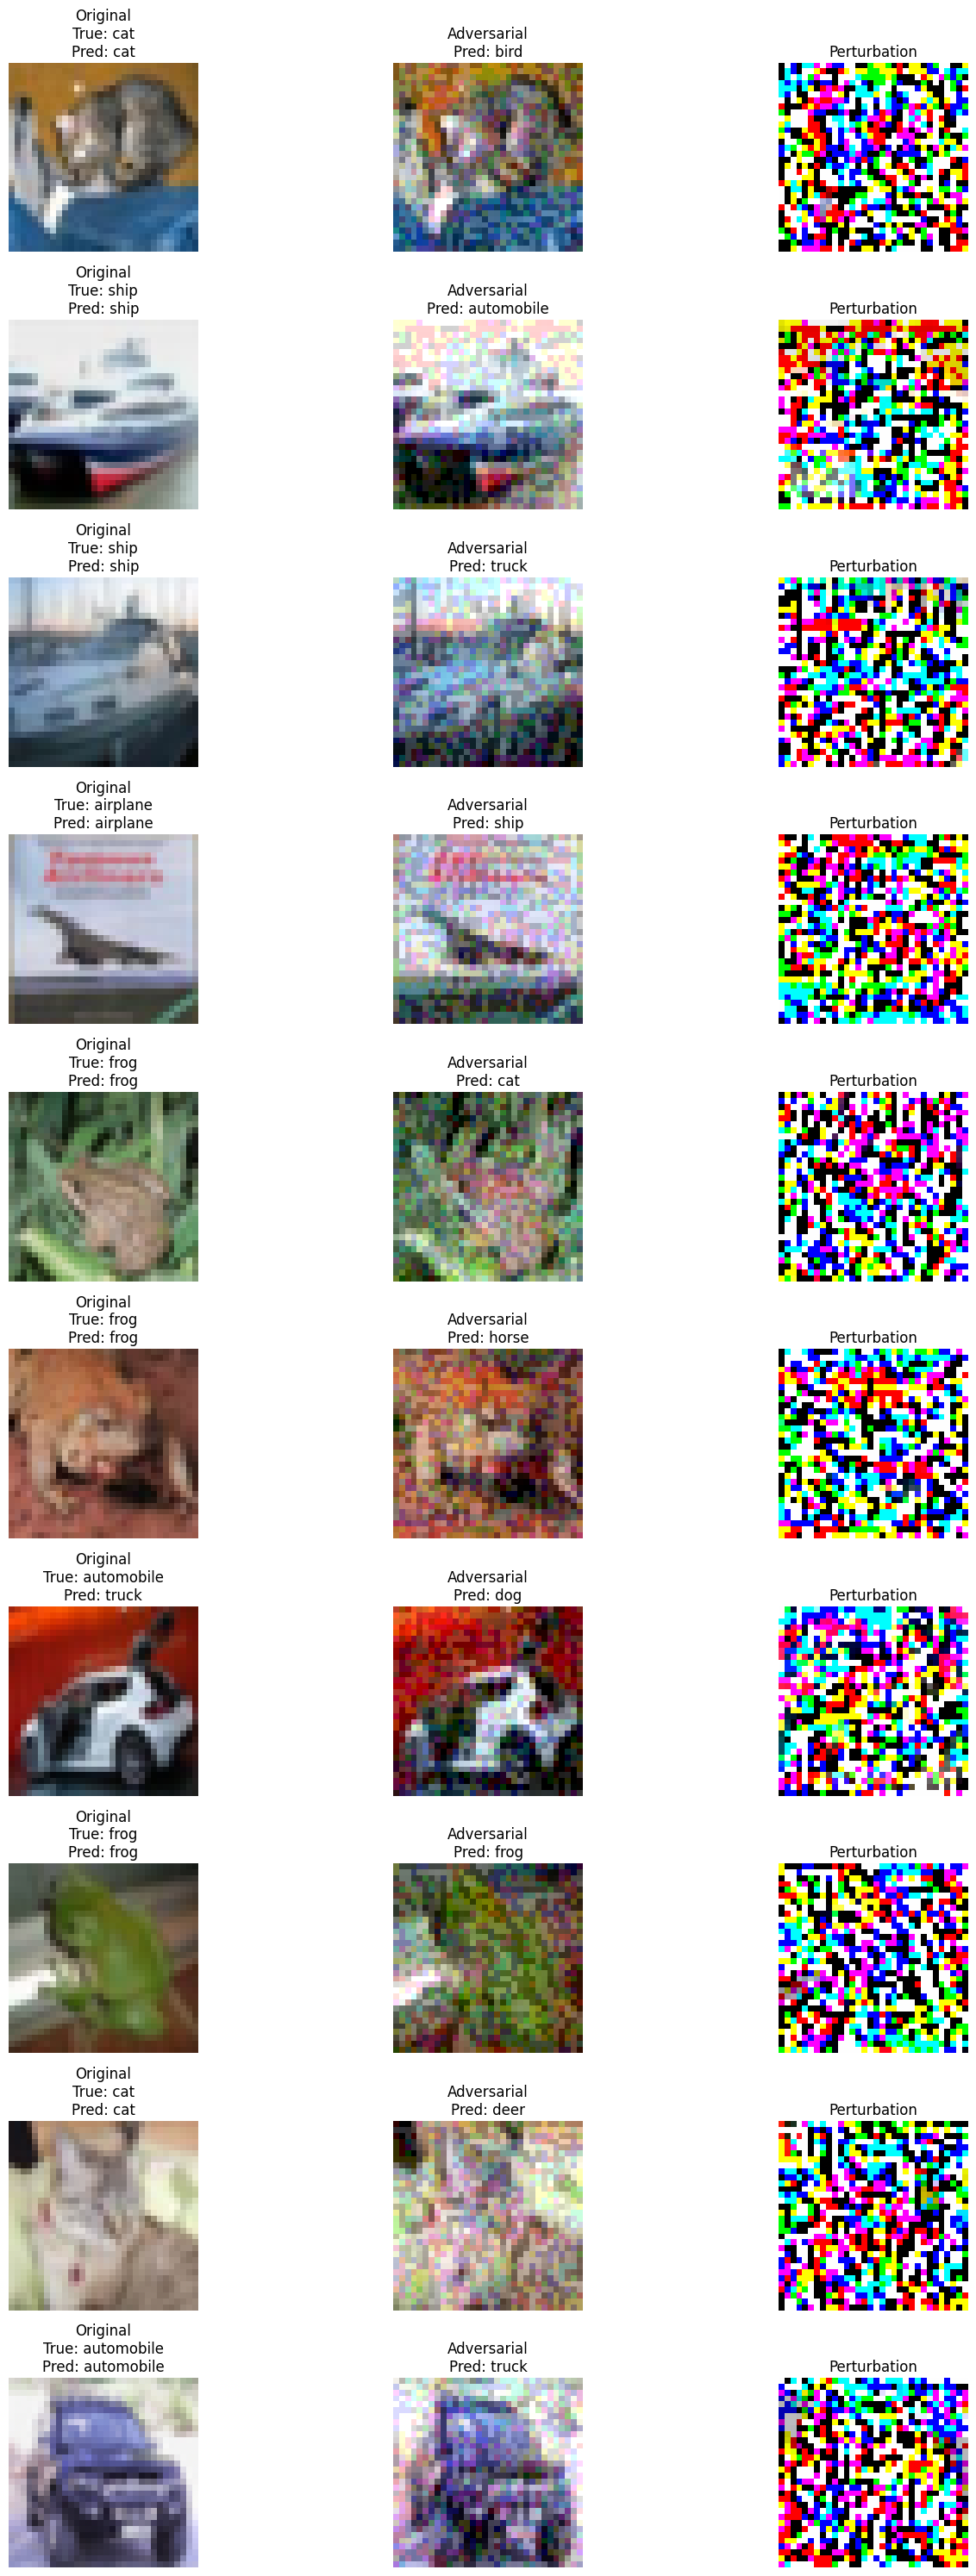

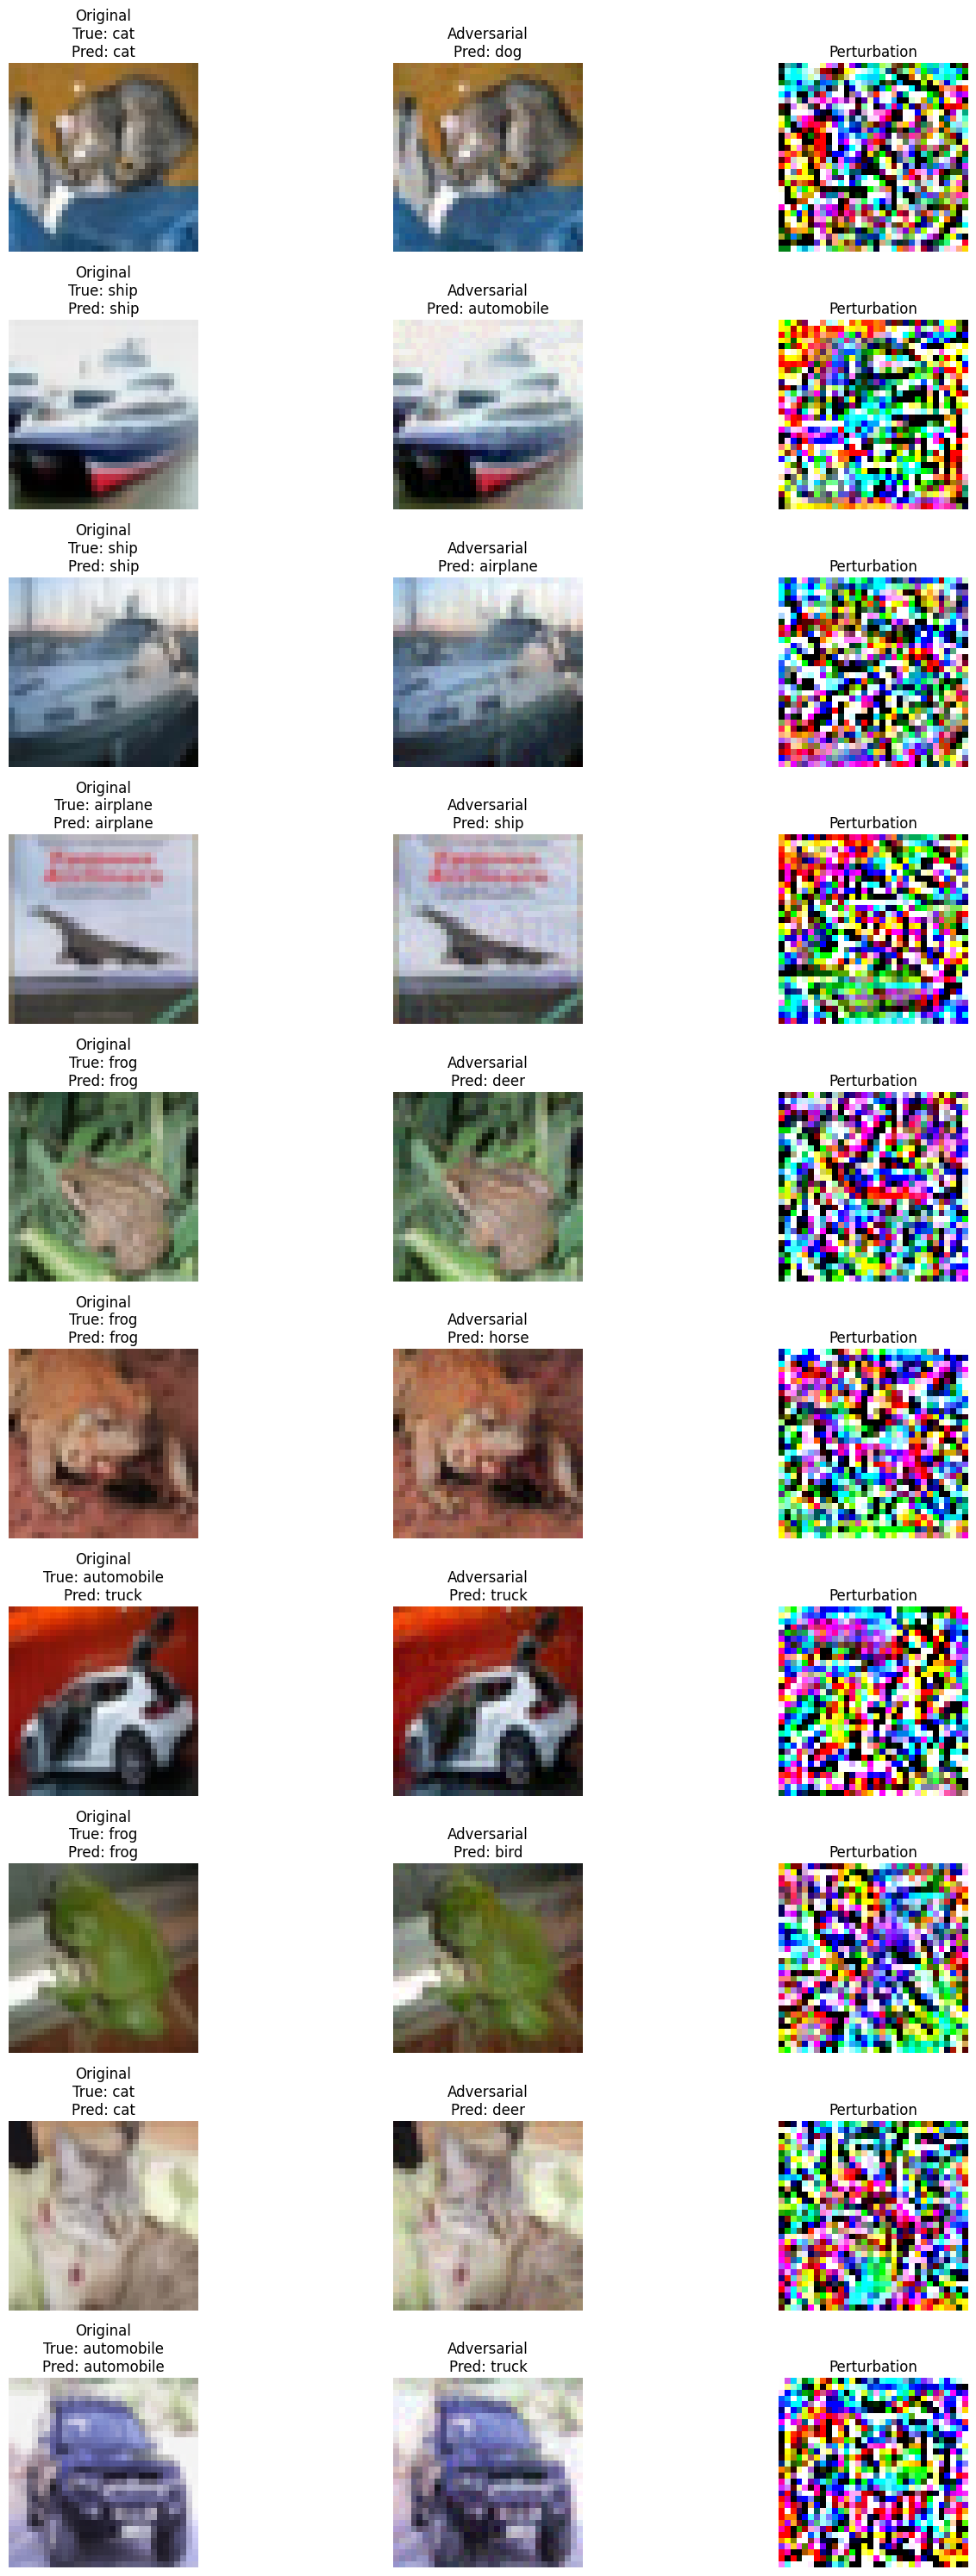

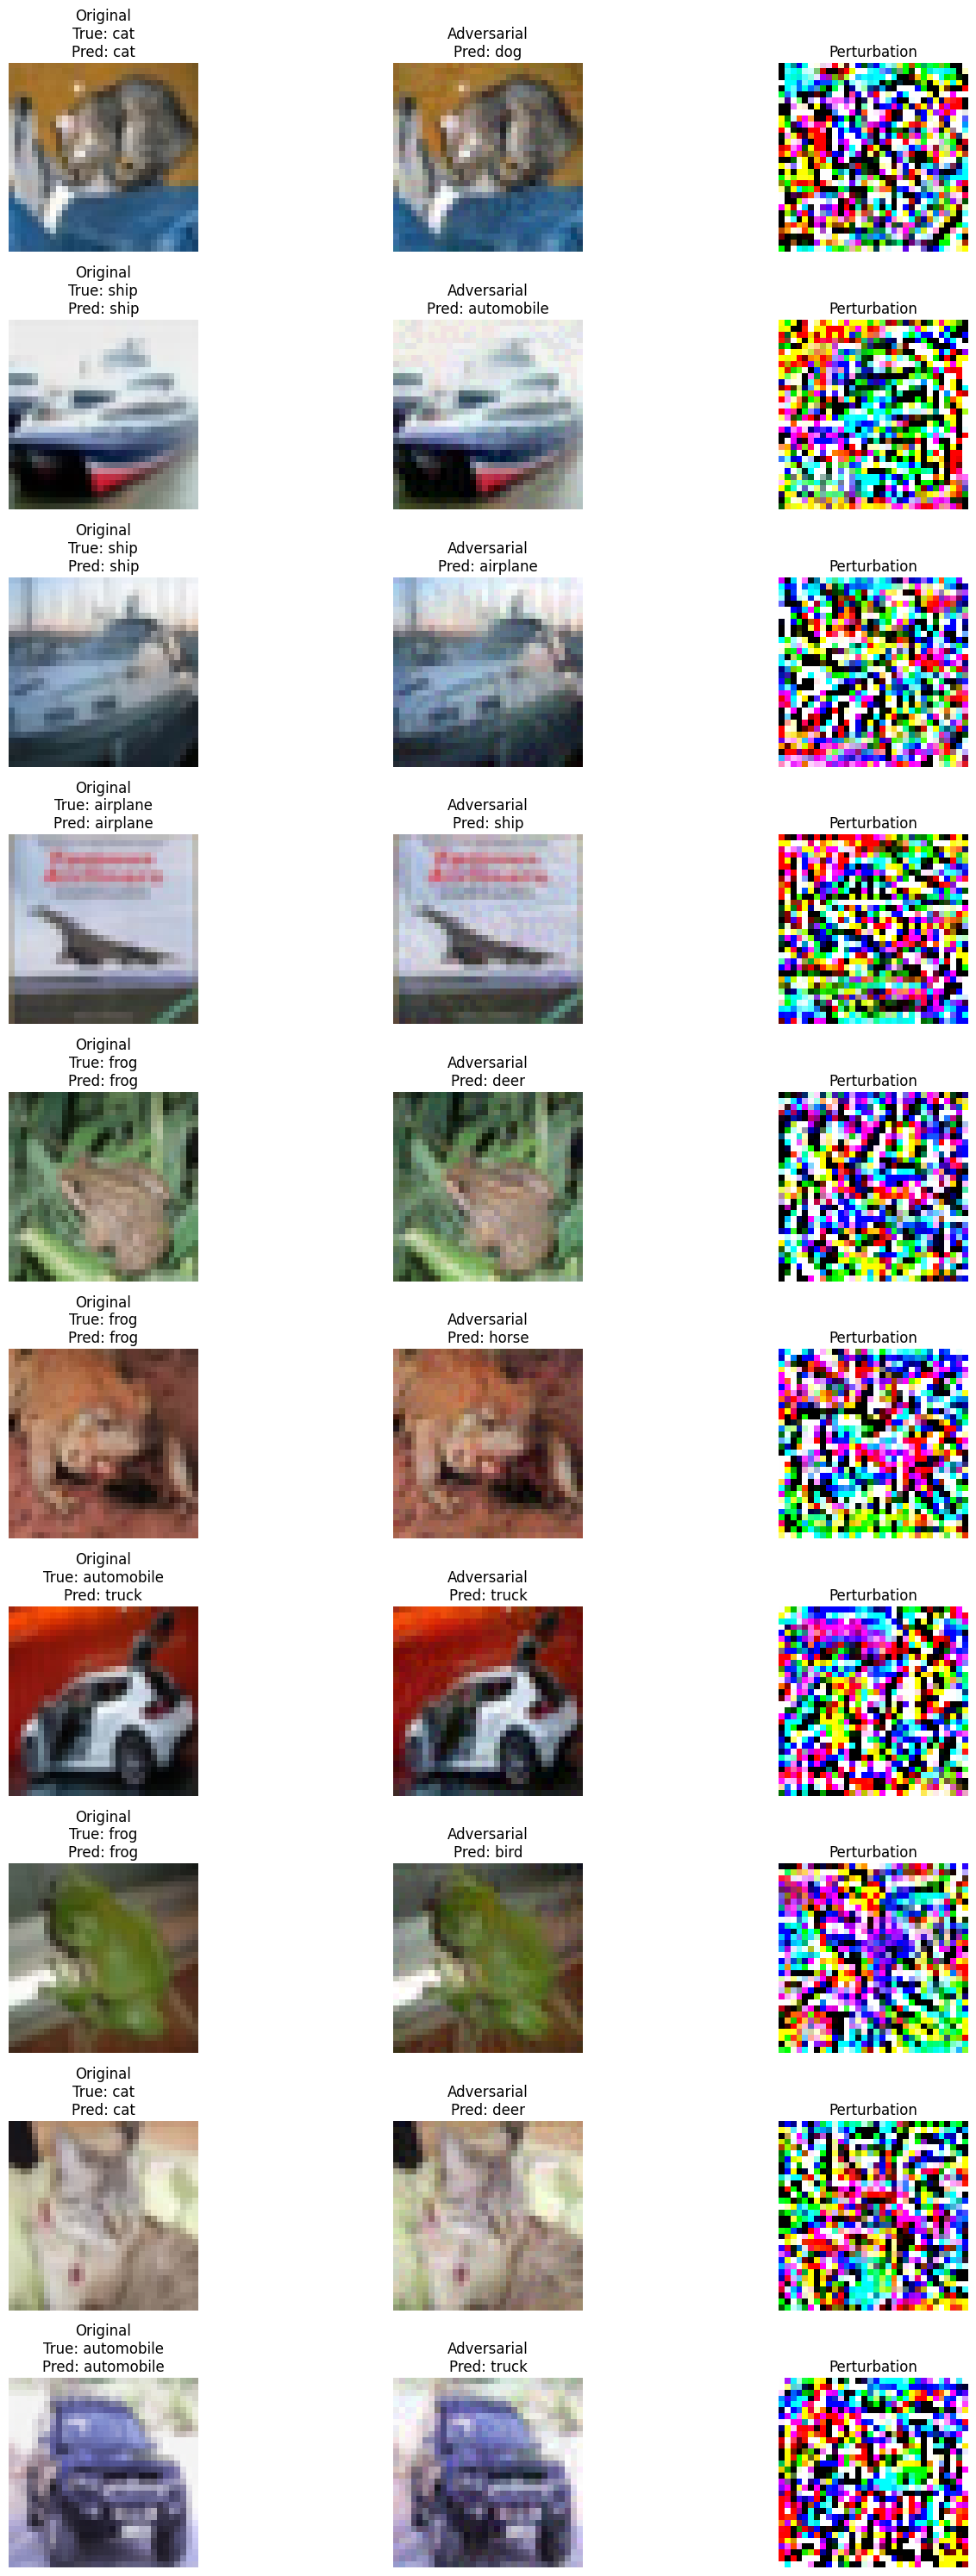

In [27]:
visualize_adversarial_examples(model, x_test, y_test, x_test_fgsm, class_names, num_examples=10)
visualize_adversarial_examples(model, x_test, y_test, x_test_bim, class_names, num_examples=10)
visualize_adversarial_examples(model, x_test, y_test, x_test_pgd, class_names, num_examples=10)

In [28]:
np.save("x_test_fgsm_eps_003.npy", x_test_fgsm)
np.save("x_test_bim.npy", x_test_bim)
np.save("x_test_pgd.npy", x_test_pgd)

print("Adversarial datasets saved.")

Adversarial datasets saved.
